In [598]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


dimension de x: (100, 2)
dimension de y: (100,)


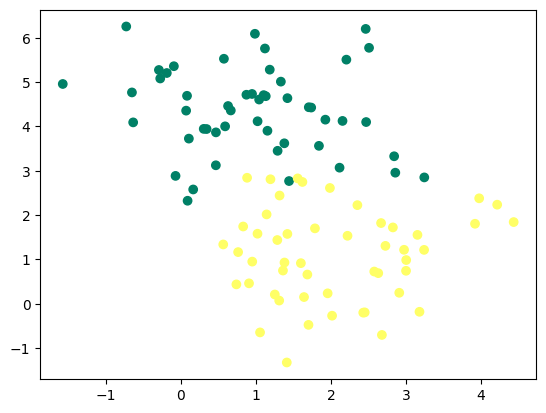

In [599]:
X,y = make_blobs(n_samples=100,n_features=2,centers=2,random_state=0)
#100 rows
# 2 variable

print("dimension de x:", X.shape)
print("dimension de y:", y.shape)

plt.scatter(X[:,0],X[:,1],c=y,cmap="summer")
plt.show()


In [600]:
print(X)

[[ 4.21850347  2.23419161]
 [ 0.90779887  0.45984362]
 [-0.27652528  5.08127768]
 [ 0.08848433  2.32299086]
 [ 3.24329731  1.21460627]
 [ 1.44193252  2.76754364]
 [ 1.0220286   4.11660348]
 [ 3.97820955  2.37817845]
 [ 0.58894326  4.00148458]
 [ 1.25185786  0.20811388]
 [ 0.62835793  4.4601363 ]
 [ 1.68608568  0.65828448]
 [ 1.18454506  5.28042636]
 [ 0.06897171  4.35573272]
 [ 1.78726415  1.70012006]
 [ 4.4384123   1.84214315]
 [ 3.18190344 -0.18226785]
 [ 0.30380963  3.94423417]
 [ 0.73936011  0.43607906]
 [ 1.28535145  1.43691285]
 [ 1.1312175   4.68194985]
 [ 0.66471755  4.35995267]
 [ 1.31570453  2.44067826]
 [-0.18887976  5.20461381]
 [ 2.57854418  0.72611733]
 [ 0.87305123  4.71438583]
 [ 1.3105127   0.07122512]
 [ 0.9867701   6.08965782]
 [ 1.42013331  4.63746165]
 [ 2.3535057   2.22404956]
 [ 2.43169305 -0.20173713]
 [ 1.0427873   4.60625923]
 [ 0.95088418  0.94982874]
 [ 2.45127423 -0.19539785]
 [ 1.62011397  2.74692739]
 [ 2.15504965  4.12386249]
 [ 1.38093486  0.92949422]
 

In [601]:
print(y)

[1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 1 0 1
 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0
 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1]


In [602]:
def initialization(X):
    W = np.random.randn(X.shape[1],1)
    b = np.random.randn(1)
    return W,b

In [603]:
W,b = initialization(X)
print(W.shape)
print(b.shape)


(2, 1)
(1,)


In [604]:
def model(X,W,b):
    Z = X.dot(W) + b
    A = 1/(1+np.exp(-Z))
    return A

In [605]:
A = model(X,W,b)
print(A.shape)

(100, 1)


In [606]:
def log_loss(A,y):
    return 1 / len(y) * np.sum(-y * np.log(A)- (1-y) * np.log(1-A))

In [607]:
print(log_loss(A,y))

119.67929453557008


In [608]:
def gradients(A,X,y):
    dw = 1/len(y) * np.dot(X.T,A-y)
    db = 1/len(y) * np.sum(A-y)
    return dw,db

In [609]:
dw,db = gradients(A,X,y)
print(dw.shape)
print(db.shape)

(2, 100)
()


In [610]:
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return W, b

In [611]:
def artificial_neuron(X,y,learning_rate=0.1,n_iter=100):
    W,b = initialization(X)
    Loss = []
    for i in range(n_iter):
        A = model(X,W,b)
        Loss.append(log_loss(A,y))
        dW,db = gradients(A,X,y)
        W,b = update(dw,db,W,b,learning_rate)
    print(Loss)
    plt.plot(Loss)
    plt.show()

[130.13601650885457, 106.85573135633251, 90.341765583208, 77.63737009640468, 66.88587720112001, 57.933472496111406, 50.54227136204344, 44.46001643052602, 39.42971753652255, 35.22641025233723, 31.672854216908508, 28.63487457516741, 26.011480409574073, 23.726836728737034, 21.724356265594388, 19.9618814988302, 18.407559390112297, 17.036450241537477, 15.827979527632253, 14.764265599160384, 13.829204545177177, 13.008071357428964, 12.287394469911213, 11.654940473568983, 11.099725040545492, 10.612011546438278, 10.18327979204521, 9.806158711541348, 9.474325499938509, 9.182379906727524, 8.925706116095014, 8.700335608397749, 8.502822827729137, 8.330141773335267, 8.179606736189418, 8.048815718085788, 7.93561186851576, 7.838057102624908, 7.754412630662488, 7.6831226529375565, 7.622799154218655, 7.5722070502003795, 7.530249718700354, 7.495955252412298, 7.468463765438887, 7.447015940631443, 7.430942838789239, 7.41965686601239, 7.412643730241056, 7.409455204113847, 7.409702531408977, 7.41305035045893

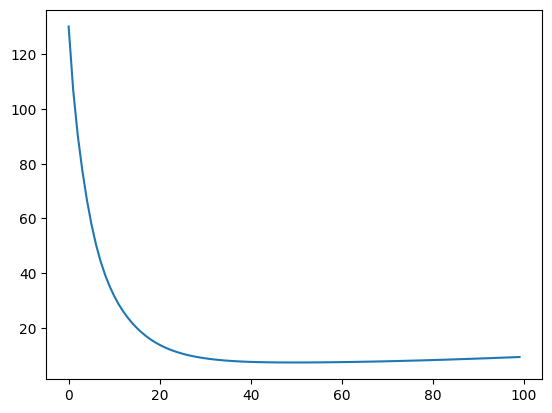

In [612]:
artificial_neuron(X,y)